Data Generation by provided code after countering an error

In [2]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data for house prices
num_samples = 10000

# Features
size = np.random.randint(500, 3000, size=num_samples)
bedrooms = np.random.randint(1, 6, size=num_samples)
bathrooms = np.random.randint(1, 4, size=num_samples)
location = np.random.choice(['City Centre', 'Suburbs', 'Rural Area'], size=num_samples)

# Target variable
prices = 50000 + (size * 100) + (bedrooms * 20000) + (bathrooms * 15000)
prices = prices.astype(float)  # Convert to float to allow adding noise
prices += np.random.normal(0, 20000, size=num_samples)  # Add noise

# Create DataFrame
data = pd.DataFrame({
    'Size': size,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Location': location,
    'Price': prices
})

# Save the dataset to a CSV file
data.to_csv('house_prices_dataset.csv', index=False)


Load/Import the Dataset and Display the First 20 Rows

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('house_prices_dataset.csv')

# Display the first 20 rows
print(df.head(20))


    Size  Bedrooms  Bathrooms     Location          Price
0   1360         5          3  City Centre  349019.010744
1   1794         3          1   Rural Area  277390.420884
2   1630         1          2   Rural Area  251406.306336
3   1595         2          1      Suburbs  283793.808416
4   2138         3          3  City Centre  342784.769425
5   2669         1          2  City Centre  383239.598371
6    966         2          3  City Centre  253915.665717
7   1738         3          3  City Centre  350262.475582
8    830         3          2  City Centre  230487.527040
9   1982         3          2   Rural Area  321429.054312
10  2635         4          1   Rural Area  388695.365372
11   630         5          2  City Centre  232932.528617
12  2185         1          1   Rural Area  242188.418196
13  1269         5          2   Rural Area  307364.281198
14  2891         5          3  City Centre  481797.542800
15  2015         5          1   Rural Area  368017.710154
16  2933      

1.2: Visualising Features ‘Size’, ‘Bedrooms’, ‘Location’, and ‘Price’

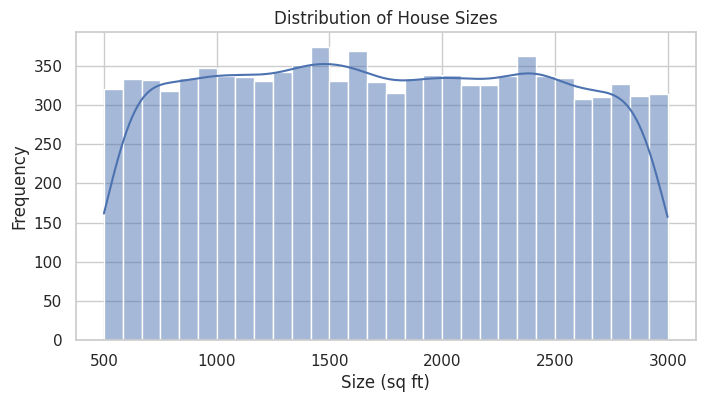

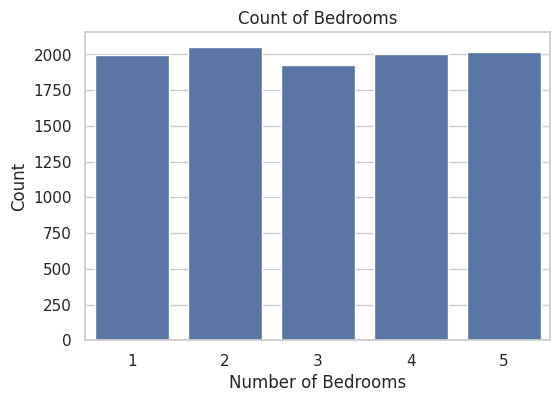

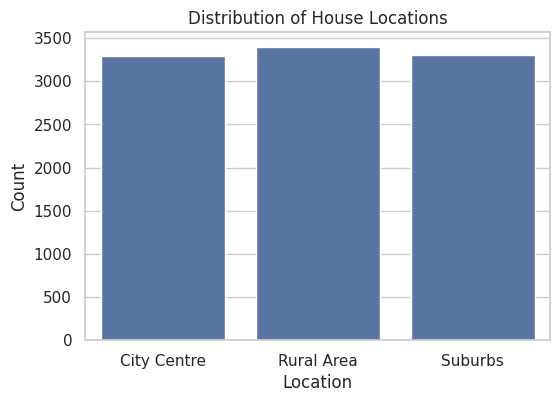

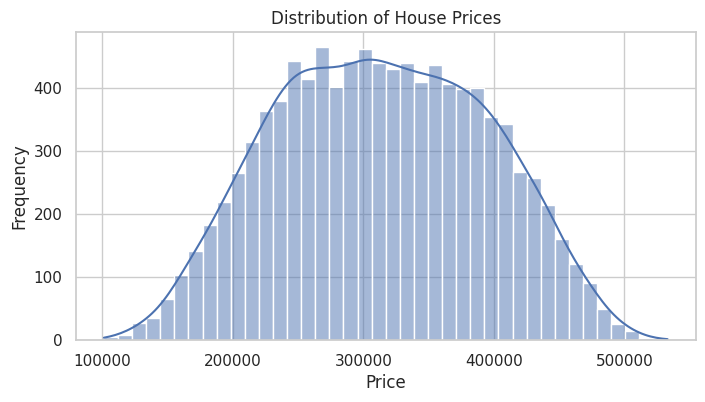

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Plot distribution of house sizes
plt.figure(figsize=(8, 4))
sns.histplot(df['Size'], bins=30, kde=True)
plt.title('Distribution of House Sizes')
plt.xlabel('Size (sq ft)')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of number of bedrooms
plt.figure(figsize=(6, 4))
sns.countplot(x='Bedrooms', data=df)
plt.title('Count of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')
plt.show()

# Plot distribution of locations
plt.figure(figsize=(6, 4))
sns.countplot(x='Location', data=df)
plt.title('Distribution of House Locations')
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

# Plot distribution of house prices
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], bins=40, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


Section 2: Model Selection and Evaluation
🔹 Subsection 2.1: Splitting the Dataset into Training and Testing Sets

In [6]:
from sklearn.model_selection import train_test_split

# One-hot encode the categorical 'Location' feature
df_encoded = pd.get_dummies(df, columns=['Location'], drop_first=True)

# Define input features (X) and target variable (y)
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

# Split dataset: 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

# Confirm dimensions of the splits
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (7000, 5)
Testing set size: (3000, 5)


2.2: Building and Evaluating Regression Models

2.3 Train and Evaluate 6 Regression Models


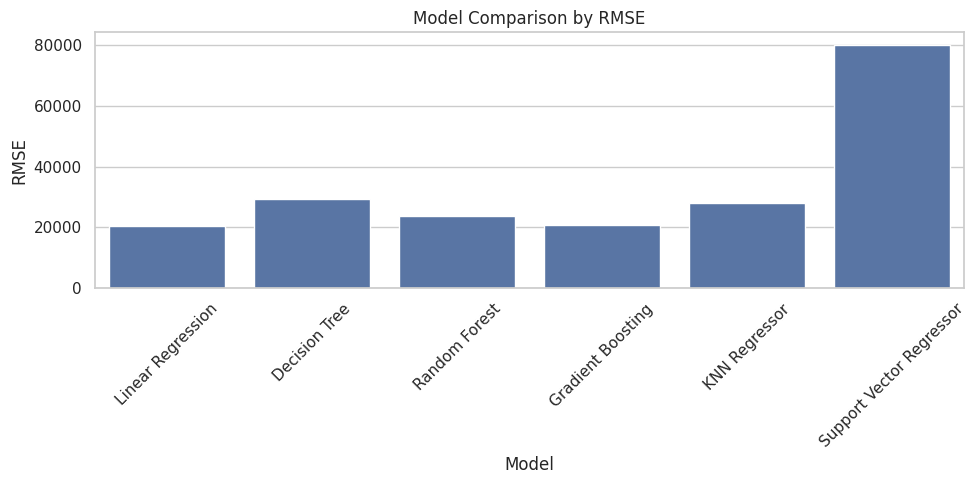

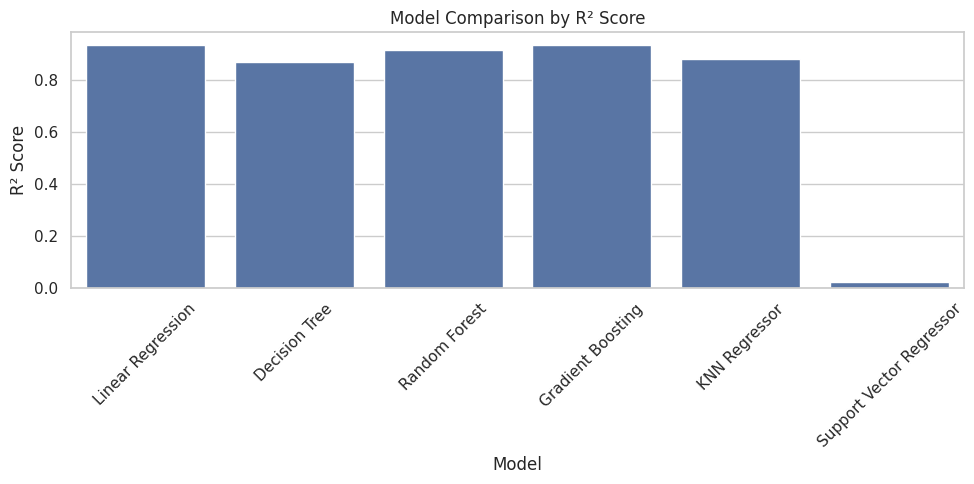

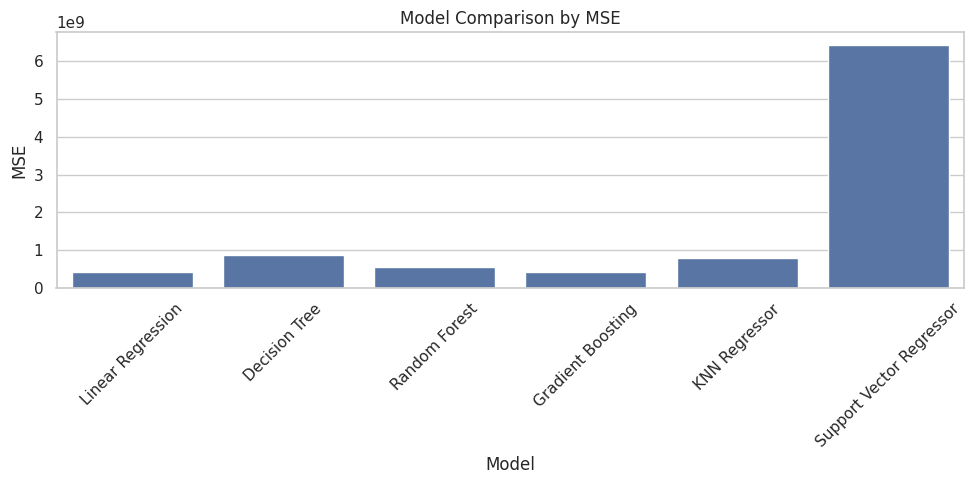

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'Support Vector Regressor': SVR(kernel='rbf')
}

# Dictionary to store evaluation results
results = {
    'Model': [],
    'MSE': [],
    'RMSE': [],
    'R2': []
}

# Train, predict, and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results['Model'].append(name)
    results['MSE'].append(mse)
    results['RMSE'].append(rmse)
    results['R2'].append(r2)

# Convert results to DataFrame
import pandas as pd
results_df = pd.DataFrame(results)

# Plot comparison graphs
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='RMSE')
plt.xticks(rotation=45)
plt.title('Model Comparison by RMSE')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='R2')
plt.xticks(rotation=45)
plt.title('Model Comparison by R² Score')
plt.ylabel('R² Score')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='MSE')
plt.xticks(rotation=45)
plt.title('Model Comparison by MSE')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()


3.1: Hyperparameter Tuning Code

In [8]:
from sklearn.model_selection import GridSearchCV

# 1. Gradient Boosting Regressor - Hyperparameter Grid
gbr = GradientBoostingRegressor(random_state=42)
gbr_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
gbr_grid = GridSearchCV(gbr, gbr_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
gbr_grid.fit(X_train, y_train)

# 2. Random Forest Regressor - Hyperparameter Grid
rf = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# 3. Linear Regression (no tuning, but included for comparison)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Print best parameters and best RMSE scores
print("Gradient Boosting Best Params:", gbr_grid.best_params_)
print("Gradient Boosting Best RMSE:", -gbr_grid.best_score_)

print("Random Forest Best Params:", rf_grid.best_params_)
print("Random Forest Best RMSE:", -rf_grid.best_score_)


Gradient Boosting Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Gradient Boosting Best RMSE: 20377.75570437694
Random Forest Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Best RMSE: 21432.435585400886


Model Saving: Exporting the Best Model for Deployment

In [9]:
import joblib

# Save the best model to a file
joblib.dump(gbr_grid.best_estimator_, 'best_house_price_model.pkl')

# To load the model later:
# loaded_model = joblib.load('best_house_price_model.pkl')
# y_pred_loaded = loaded_model.predict(X_test)


['best_house_price_model.pkl']

Gradio Code to Deploy the Best Model

In [11]:
import gradio as gr
import joblib
import numpy as np

# Load the best saved model
model = joblib.load("best_house_price_model.pkl")

# Define prediction function with input validation
def predict_price(size, bedrooms, bathrooms, location):
    # Validation checks
    if size <= 0:
        return "❌ Error: Size must be a positive value."
    if bedrooms < 1 or bedrooms > 5:
        return "❌ Error: Bedrooms must be between 1 and 5."
    if bathrooms < 1 or bathrooms > 3:
        return "❌ Error: Bathrooms must be between 1 and 3."

    # Encode location using one-hot encoding
    loc_suburbs = 1 if location == "Suburbs" else 0
    loc_rural = 1 if location == "Rural Area" else 0
    input_features = np.array([[size, bedrooms, bathrooms, loc_rural, loc_suburbs]])

    # Predict and format the result
    predicted_price = model.predict(input_features)[0]
    return f"✅ Estimated House Price: £{predicted_price:,.2f}"

# Gradio interface definition
interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="Size (sq ft)", value=1000, minimum=100, maximum=10000, precision=0),
        gr.Slider(1, 5, step=1, label="Number of Bedrooms"),
        gr.Slider(1, 3, step=1, label="Number of Bathrooms"),
        gr.Radio(["City Centre", "Suburbs", "Rural Area"], label="Location")
    ],
    outputs="text",
    title="House Price Predictor",
    description="Enter property details to predict the house price using a Gradient Boosting model. Inputs must be within valid ranges."
)

# Launch the app
interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ac848d83ab6f46d34b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
